<a href="https://colab.research.google.com/github/thasleenasaleem/pl/blob/main/EXP%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
#load diabetes
diabetes = load_diabetes()
x=diabetes.data
y=diabetes.target
#train_ test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#future
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
print("training samples:",x_train.shape[0])
print("testing samples:",x_test.shape[0])


training samples: 353
testing samples: 89


In [10]:
linear_model=LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear=linear_model.predict(x_test)
print("linear regression")
print("MSE :",mean_squared_error(y_test,y_pred_linear))
print("R2 =",r2_score(y_test,y_pred_linear))
ridge =Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
best_ridge = ridge_cv.fit(x_train, y_train)
best_ridge_model = best_ridge.best_estimator_
y_pred_ridge = best_ridge_model.predict(x_test)


linear regression
MSE : 2900.1936284934823
R2 = 0.45260276297191926


In [14]:
print("best ALpha for Ridge:",ridge_cv.best_params_['alpha'])
print('MSE=',mean_squared_error(y_test,y_pred_ridge))
print('R2=',r2_score(y_test,y_pred_ridge))

best ALpha for Ridge: 10
MSE= 2875.7787184218428
R2= 0.4572109567780849


In [25]:
lasso=Lasso(max_iter=10000)
lasso_cv=GridSearchCV(lasso,param_grid,cv=5)
lasso_cv.fit(x_train,y_train)
best_lasso=lasso_cv.best_estimator_
y_pred_lasso=best_lasso.predict(x_test)
print("best alpha for lasso:",lasso_cv.best_params_['alpha'])
print("MSE:",mean_squared_error(y_test,y_pred_lasso))
print("R2:",r2_score(y_test,y_pred_lasso))

best alpha for lasso: 1
MSE: 2824.568094049959
R2: 0.46687670944102466


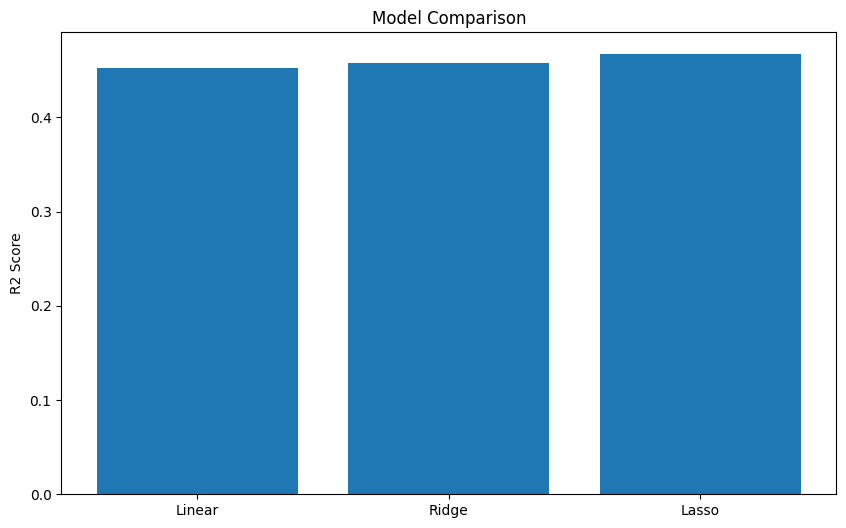

In [24]:
plt.figure(figsize=(10,6))
models=['Linear','Ridge','Lasso']
r2_scores=[
r2_score(y_test,y_pred_linear),
r2_score(y_test,y_pred_ridge),
r2_score(y_test,y_pred_lasso)
]
plt.bar(models,r2_scores)
plt.ylabel('R2 Score')
plt.title('Model Comparison')
plt.show()